# Customer Segmentation Dashboard

## Business Objective

The objective of this notebook is to create an interactive business dashboard that summarizes customer segments generated using K-Means clustering.

The dashboard enables decision-makers to quickly understand customer behavior, identify valuable customers, and design targeted marketing strategies.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
rfm = pd.read_csv(
    "C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\DATA\\RAW\\processed\\customer_segments.csv",
    index_col=0
)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,165,11,372.86,3,Loyal Customers
12347.0,3,2,1323.32,0,Potential Customers
12348.0,74,1,222.16,2,Lost Customers
12349.0,43,3,2671.14,3,Loyal Customers
12351.0,11,1,300.93,0,Potential Customers


In [5]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4312 entries, 12346.0 to 18287.0
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4312 non-null   int64  
 1   Frequency  4312 non-null   int64  
 2   Monetary   4312 non-null   float64
 3   Cluster    4312 non-null   int64  
 4   Segment    4312 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 202.1+ KB


## Load Customer Segmentation Results

The original RFM dataset with customer segment labels is loaded to build business visualizations.

In [6]:
rfm = pd.read_csv(
    "C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\DATA\\RAW\\processed\\customer_segments.csv",
    index_col=0
)

cluster_names = {
    0: "Potential Customers",
    1: "Champions",
    2: "Lost Customers",
    3: "Loyal Customers"
}

if "Cluster" in rfm.columns:
    rfm["Segment"] = rfm["Cluster"].map(cluster_names)
else:
    rfm["Segment"] = pd.NA
    print("Warning: 'Cluster' column not found in the loaded data. Segment values are unavailable.")

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346.0,165,11,372.86,3,Loyal Customers
12347.0,3,2,1323.32,0,Potential Customers
12348.0,74,1,222.16,2,Lost Customers
12349.0,43,3,2671.14,3,Loyal Customers
12351.0,11,1,300.93,0,Potential Customers


## Customer Distribution by Segment

This chart shows the number of customers present in each customer segment identified by the K-Means clustering algorithm.

Understanding the size of each segment helps businesses prioritize marketing strategies and allocate resources efficiently.

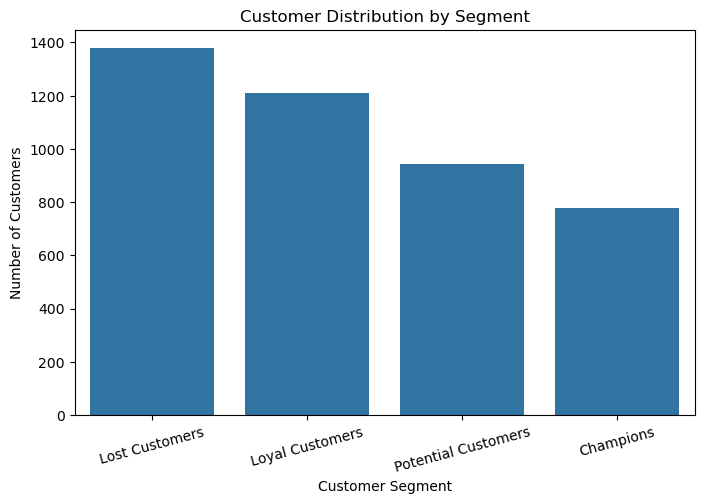

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="Segment",
    order=rfm["Segment"].value_counts().index
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

In [15]:
plt.savefig("C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\images", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>

### Observation

The visualization shows how customers are distributed across the four customer segments. A balanced distribution indicates that the clustering algorithm successfully identified meaningful customer groups rather than concentrating most customers into a single cluster.

## Average RFM Values by Segment

To better understand customer behavior, we calculate the average Recency, Frequency, and Monetary values for each customer segment.

These metrics help identify which groups are the most valuable and which require targeted marketing efforts.

In [8]:
segment_summary = (
    rfm.groupby("Segment")[["Recency","Frequency","Monetary"]]
       .mean()
       .round(2)
)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
Champions,13.83,13.56,7381.58
Lost Customers,190.57,1.30,305.66
Loyal Customers,80.21,4.14,1759.99
Potential Customers,23.95,1.97,532.08


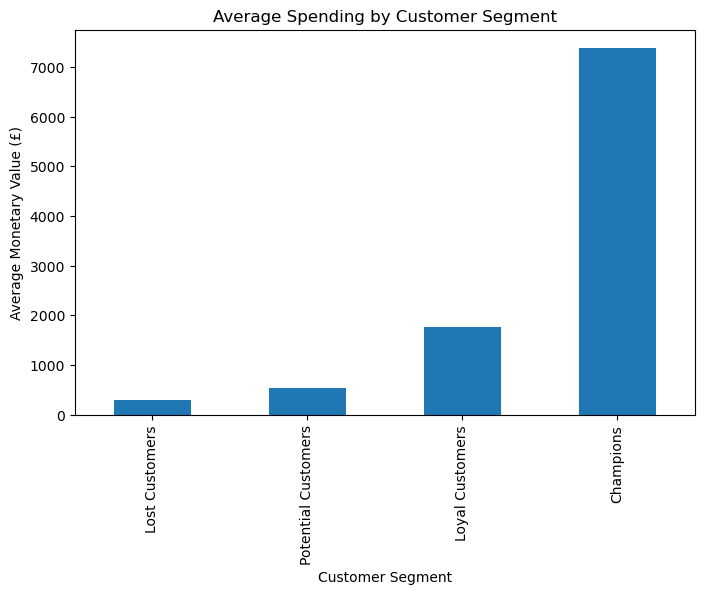

In [9]:
plt.figure(figsize=(8,5))

segment_summary["Monetary"].sort_values().plot(kind="bar")

plt.title("Average Spending by Customer Segment")
plt.ylabel("Average Monetary Value (£)")
plt.xlabel("Customer Segment")

plt.show()

### Observation

Champions have the highest average spending, making them the most valuable customer segment.

Potential Customers and Lost Customers contribute significantly less revenue, highlighting opportunities for customer engagement and retention.

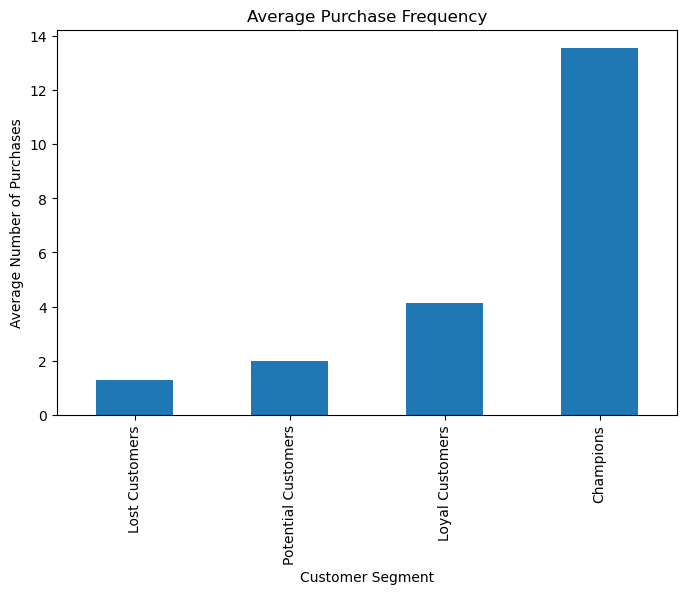

In [11]:
plt.figure(figsize=(8,5))

segment_summary["Frequency"].sort_values().plot(kind="bar")

plt.title("Average Purchase Frequency")
plt.ylabel("Average Number of Purchases")
plt.xlabel("Customer Segment")

plt.show()

### Observation

Champions purchase products most frequently, while Lost Customers purchase the least.

Increasing purchase frequency among Potential and Loyal Customers can lead to higher long-term revenue.

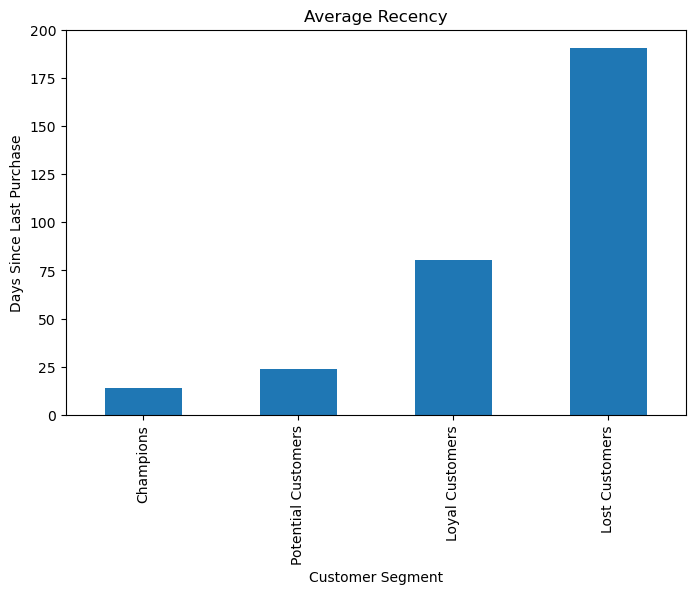

In [12]:
plt.figure(figsize=(8,5))

segment_summary["Recency"].sort_values().plot(kind="bar")

plt.title("Average Recency")
plt.ylabel("Days Since Last Purchase")
plt.xlabel("Customer Segment")

plt.show()

### Observation

Champions have the lowest Recency value, meaning they purchased recently.

Lost Customers have the highest Recency value, indicating that they have not interacted with the business for a long time.

## Customer Segment Comparison

A heatmap provides a consolidated comparison of the average RFM values across all customer segments.

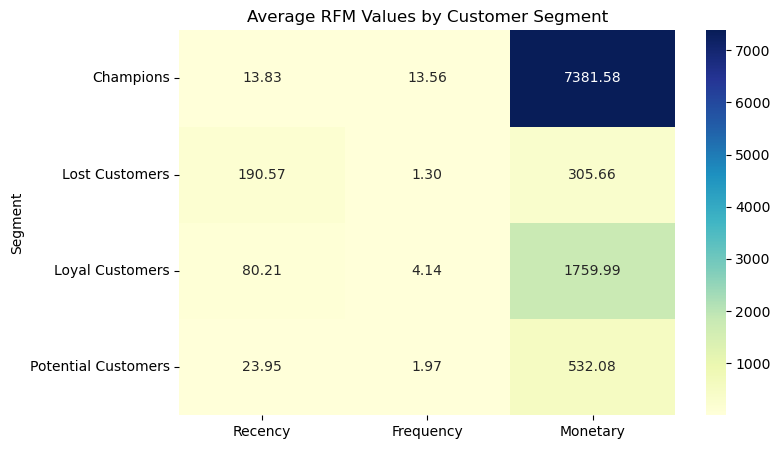

In [14]:
plt.figure(figsize=(8,5))

sns.heatmap(
    segment_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Average RFM Values by Customer Segment")

plt.show()

### Observation

The heatmap clearly highlights the behavioral differences between customer segments.

- Champions have the highest purchase frequency and spending with the lowest recency.
- Lost Customers exhibit low spending, infrequent purchases, and long inactivity.
- Loyal Customers maintain moderate purchase behavior.
- Potential Customers have purchased recently but have not yet become frequent buyers.

# Executive Summary

This dashboard summarizes the customer segmentation results obtained using K-Means clustering on RFM features.

Key Insights:

- Champions are the highest-value customers and should be rewarded through loyalty programs and exclusive offers.
- Loyal Customers contribute steady revenue and present opportunities for upselling and cross-selling.
- Potential Customers should be encouraged to make repeat purchases through personalized marketing campaigns.
- Lost Customers require targeted re-engagement strategies such as discounts or promotional offers.

These insights enable businesses to implement data-driven marketing strategies, improve customer retention, and maximize overall revenue.